### Importing libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from matplotlib.patches import Patch

sns.set_theme(style='darkgrid')

### Loading data

In [2]:
data = pd.read_csv('Linhac24-25_Sportlogiq.csv')
sorted_data = data.sort_values(by=['gameid', 'compiledgametime']).copy()

print(f'Rows: {len(data):,}')
print(f'Games: {data["gameid"].nunique()}')
print(f'Teams: {data["teamid"].nunique()}\n')
print(data['manpowersituation'].value_counts())

Rows: 541,802
Games: 156
Teams: 14

manpowersituation
evenStrength    463668
powerPlay        59271
shortHanded      18863
Name: count, dtype: int64


### Checking missing values

In [3]:
data.isnull().sum()

gameid                                0
opposingteamgoalieoniceid          3266
opposingteamid                        0
playerid                              0
teamgoalieoniceid                  7080
teamid                                0
teaminpossession                  73890
currentpossession                 73890
xg_allattempts                   525454
compiledgametime                      0
eventname                             0
ishomegame                            0
manpowersituation                     0
opposingteamskatersonicecount         0
outcome                               0
period                                0
playerprimaryposition                 0
scoredifferential                     0
teamskatersonicecount                 0
type                                  0
xadjcoord                             0
yadjcoord                             0
dtype: int64

# What separates PP sequences that lead to goals from those that don't

#### Each PP sequence is split by gaps > 10s. Features extracted per sequence: passes, carries, duration, zone entries, shots.

In [4]:
# ändra -  en sekvens är från att man kommer in i zon till skott
pp_seq_features = []

for game, game_df in data.groupby('gameid'):
    game_df = game_df.sort_values('compiledgametime')
    pp = game_df[game_df['manpowersituation'] == 'powerPlay'].copy()
    if len(pp) == 0: continue
    pp['time_gap'] = pp['compiledgametime'].diff()
    pp['new_seq']  = (pp['time_gap'] > 10) | pp['time_gap'].isna()
    pp['seq_id']   = pp['new_seq'].cumsum()

    for seq_id, seq in pp.groupby('seq_id'):
        if len(seq) < 3: continue
        entries = seq[seq['eventname'] == 'controlledentry']['type']
        if len(entries) > 0:
            t = entries.iloc[0]
            entry_type = 'carry' if str(t).startswith('carry') else ('pass' if str(t).startswith('pass') else 'other')
        else:
            entry_type = 'no_entry'

        pp_seq_features.append({
            'teamid':       seq['teamid'].mode()[0],
            'goal':         int((seq['eventname'] == 'goal').any()),
            'n_passes':     (seq['eventname'] == 'pass').sum(),
            'n_carries':    (seq['eventname'] == 'carry').sum(),
            'n_shots':      seq['eventname'].isin(['shot', 'goal']).sum(),
            'n_entries':    (seq['eventname'] == 'controlledentry').sum(),
            'duration':     seq['compiledgametime'].max() - seq['compiledgametime'].min(),
            'entry_type':   entry_type,
            'mean_xg':      seq['xg_allattempts'].mean() if seq['xg_allattempts'].notna().any() else 0,
        })

seq_df = pd.DataFrame(pp_seq_features)
print(f'Total PP sequences: {len(seq_df)}')
print(f'Goal sequences:     {seq_df["goal"].sum()} ({seq_df["goal"].mean()*100:.1f}%)')
print(f'No-goal sequences:  {(1-seq_df["goal"]).sum()}')
print()
print(seq_df.groupby('goal')[['n_passes','n_carries','n_shots','duration','mean_xg']].mean().round(2))

Total PP sequences: 962
Goal sequences:     184 (19.1%)
No-goal sequences:  778

      n_passes  n_carries  n_shots  duration  mean_xg
goal                                                 
0        20.55       4.17     2.39     82.73     0.04
1        18.93       2.74     4.12     66.73     0.12


In [5]:
# Individual events from each PP sequence that contains a goal
goal_seqs = []
gid = 0
for game, game_df in data.groupby('gameid'):
    game_df = game_df.sort_values('compiledgametime')
    pp = game_df[game_df['manpowersituation'] == 'powerPlay'].copy()
    if len(pp) == 0: continue
    pp['time_gap'] = pp['compiledgametime'].diff()
    pp['new_seq']  = (pp['time_gap'] > 10) | pp['time_gap'].isna()
    pp['seq_id']   = pp['new_seq'].cumsum()
    for seq_id, seq in pp.groupby('seq_id'):
        if len(seq) >= 3 and (seq['eventname'] == 'goal').any():
            s = seq.copy()
            s['goal_id'] = gid
            goal_seqs.append(s)
            gid += 1

pp_sequences = pd.concat(goal_seqs, ignore_index=True)
print(f'PP goal sequences: {pp_sequences["goal_id"].nunique()}')
print(pp_sequences['eventname'].value_counts().head(8))

PP goal sequences: 184
eventname
pass              3483
reception         3178
lpr               1209
shot               569
carry              504
assist             367
faceoff            299
controlledexit     281
Name: count, dtype: int64


### Example PP goal sequence

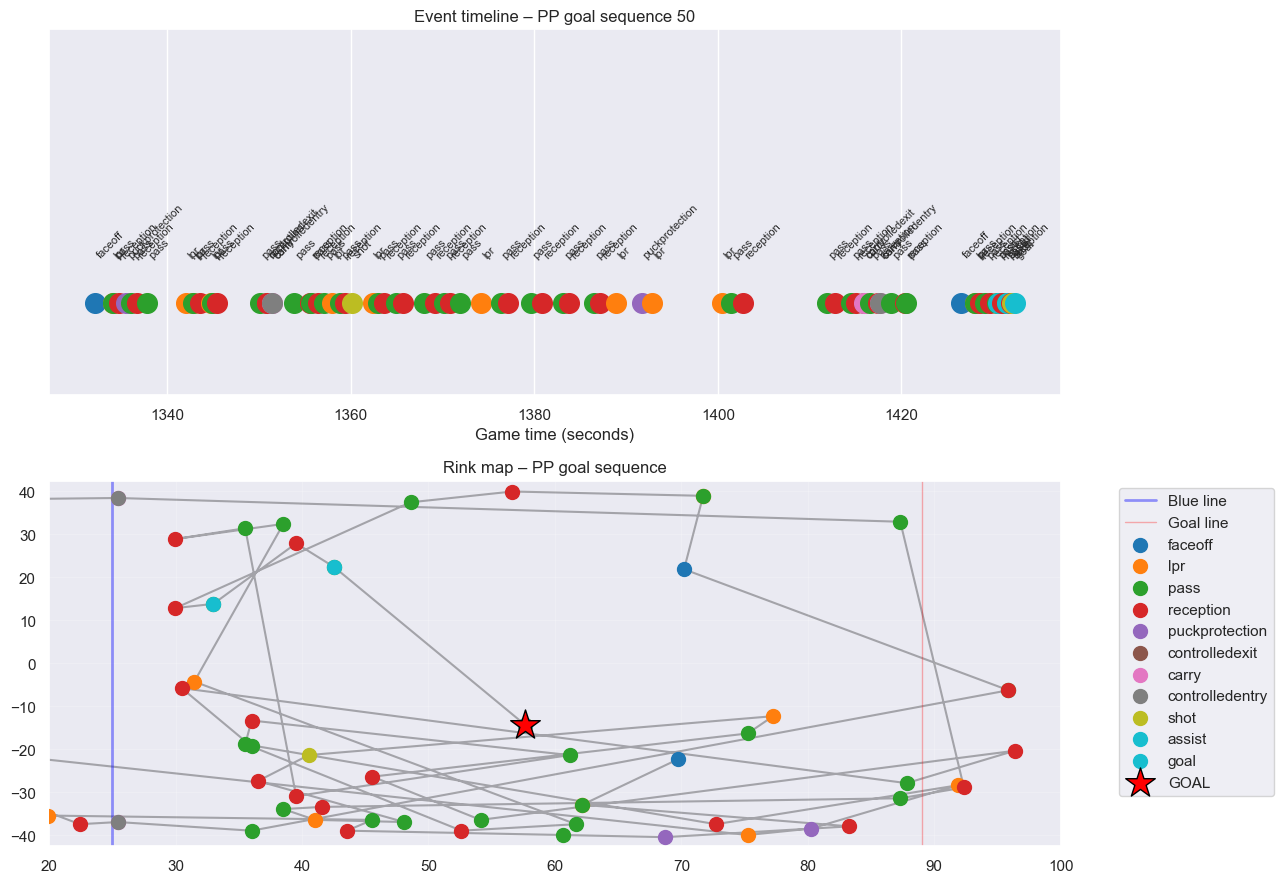

In [6]:
goal_id_to_plot = 50
single_seq = pp_sequences[pp_sequences['goal_id'] == goal_id_to_plot]

evts = single_seq['eventname'].unique()
cmap = plt.cm.tab10
colors_map = {e: cmap(i / max(len(evts) - 1, 1)) for i, e in enumerate(evts)}

fig, axes = plt.subplots(2, 1, figsize=(13, 9))

# Event timeline
ax = axes[0]
for _, row in single_seq.iterrows():
    ax.scatter(row['compiledgametime'], 1, color=colors_map[row['eventname']], s=200, zorder=3)
    ax.text(row['compiledgametime'], 1.05, row['eventname'], rotation=45, ha='left', fontsize=8)
ax.set_title(f'Event timeline – PP goal sequence {goal_id_to_plot}')
ax.set_xlabel('Game time (seconds)'); ax.set_yticks([]); ax.set_ylim(0.9, 1.3)

# Rink map
ax = axes[1]
ax.axvline(25, color='blue', linewidth=2, alpha=0.4, label='Blue line')
ax.axvline(89, color='red', linewidth=1, alpha=0.3, label='Goal line')
ax.plot(single_seq['xadjcoord'], single_seq['yadjcoord'], color='black', alpha=0.3, zorder=1)
for evt in evts:
    sub = single_seq[single_seq['eventname'] == evt]
    ax.scatter(sub['xadjcoord'], sub['yadjcoord'], label=evt, s=100, zorder=3, color=colors_map[evt])
goal_row = single_seq[single_seq['eventname'] == 'goal']
if not goal_row.empty:
    ax.scatter(goal_row['xadjcoord'], goal_row['yadjcoord'],
               color='red', marker='*', s=500, label='GOAL', zorder=5, edgecolors='black')
ax.set_xlim(20, 100); ax.set_ylim(-42.5, 42.5)
ax.set_title('Rink map – PP goal sequence')
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
ax.grid(True, alpha=0.2)
plt.tight_layout(); plt.show()

### Last 10 events before a PP goal

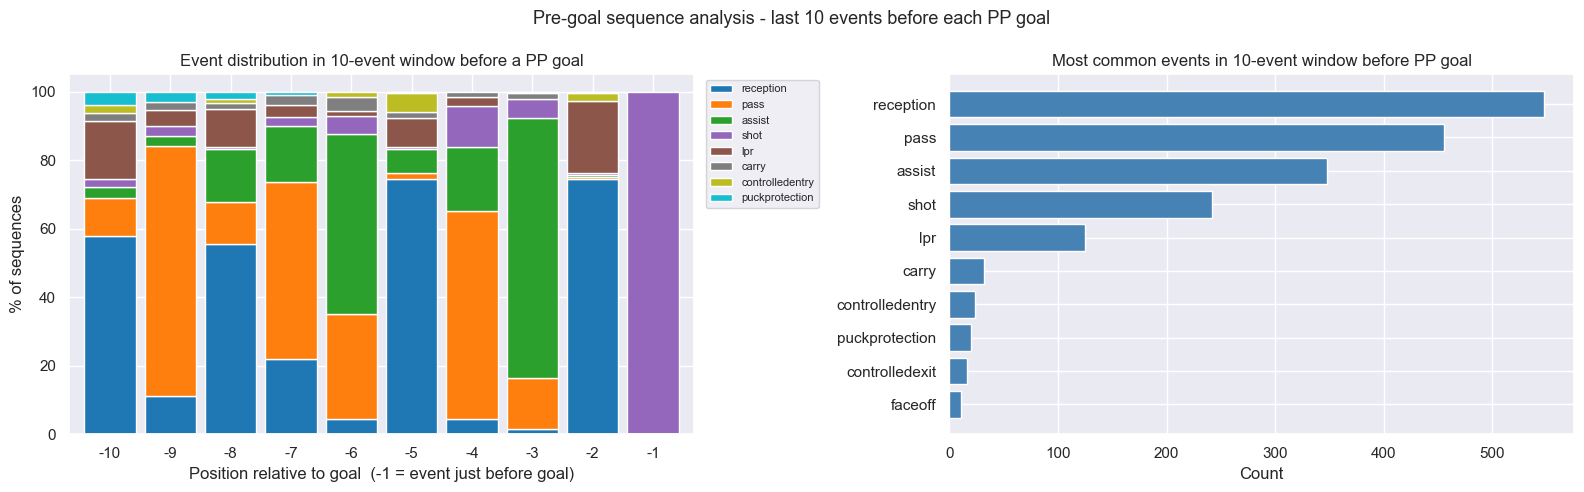

Event counts in 10-event pre-goal window:
eventname
reception          548
pass               456
assist             348
shot               242
lpr                125
carry               32
controlledentry     24
puckprotection      20
controlledexit      16
faceoff             11
Name: count, dtype: int64


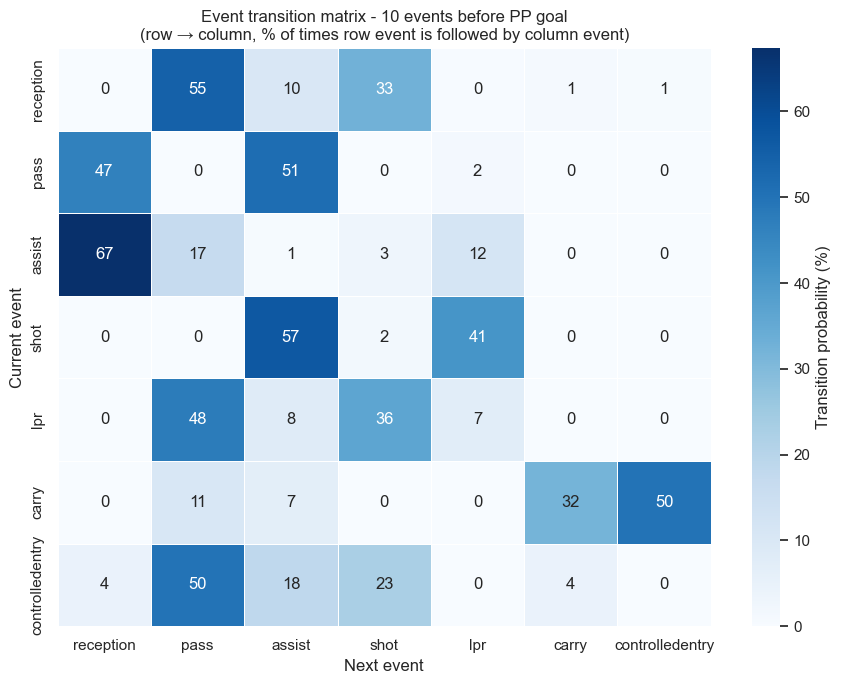

In [ ]:
from collections import defaultdict

# Build a record for every event in the 10-event window before each PP goal
pre_goal_records = []

for goal_id, seq in pp_sequences.groupby('goal_id'):
    seq = seq.sort_values('compiledgametime')
    goal_row = seq[seq['eventname'] == 'goal']
    if goal_row.empty:
        continue
    goal_time = goal_row['compiledgametime'].iloc[0]
    pre = seq[seq['compiledgametime'] < goal_time]
    last_10 = pre.tail(10).reset_index(drop=True)
    n = len(last_10)
    for i, (_, row) in enumerate(last_10.iterrows()):
        pre_goal_records.append({
            'goal_id': goal_id,
            'pos': i - n,   # -n … -1;  -1 = event immediately before goal
            'eventname': row['eventname'],
        })

pre_goal_df = pd.DataFrame(pre_goal_records)
freq = pre_goal_df['eventname'].value_counts()
top_events = freq.head(8).index.tolist()

# Plot: stacked bar by position + overall frequency
pivot = pre_goal_df.pivot_table(index='pos', columns='eventname', aggfunc='size', fill_value=0)
pivot_pct = pivot[top_events].div(pivot[top_events].sum(axis=1), axis=0) * 100

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

pivot_pct.plot(kind='bar', stacked=True, ax=axes[0], colormap='tab10', width=0.85)
axes[0].set_xlabel('Position relative to goal  (-1 = event just before goal)')
axes[0].set_ylabel('% of sequences')
axes[0].set_title('Event distribution in 10-event window before a PP goal')
axes[0].legend(bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=8)
axes[0].tick_params(axis='x', rotation=0)

axes[1].barh(freq.index[:10][::-1], freq.values[:10][::-1], color='steelblue', edgecolor='white')
axes[1].set_xlabel('Count')
axes[1].set_title('Most common events in 10-event window before PP goal')

plt.suptitle('Pre-goal sequence analysis - last 10 events before each PP goal', fontsize=13)
plt.tight_layout()
plt.show()

print('Event counts in 10-event pre-goal window:')
print(freq.head(10))

# Plot: event transition matrix
transitions = defaultdict(lambda: defaultdict(int))
for goal_id, grp in pre_goal_df.groupby('goal_id'):
    evts = grp.sort_values('pos')['eventname'].tolist()
    for a, b in zip(evts[:-1], evts[1:]):
        transitions[a][b] += 1

top7 = freq.head(7).index.tolist()
trans_matrix = pd.DataFrame(
    {col: [transitions[row][col] for row in top7] for col in top7},
    index=top7
)
trans_pct = trans_matrix.div(trans_matrix.sum(axis=1).replace(0, np.nan), axis=0) * 100

fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(trans_pct.fillna(0).round(1), annot=True, fmt='.0f', cmap='Blues', ax=ax,
            linewidths=0.5, cbar_kws={'label': 'Transition probability (%)'})
ax.set_title('Event transition matrix - 10 events before PP goal\n(row → column, % of times row event is followed by column event)')
ax.set_xlabel('Next event')
ax.set_ylabel('Current event')
plt.tight_layout()
plt.show()

### Clustering PP goal sequences

Average features per cluster:
         x_mean  x_min  y_std  num_passes  num_carries  total_events  duration
cluster                                                                       
0         57.73  23.43  21.70       10.16         0.14         30.33     29.06
1         31.74 -88.78  24.82       20.84         3.57         64.79     76.69
2         34.70 -97.57  25.10       87.75        15.25        257.75    308.98


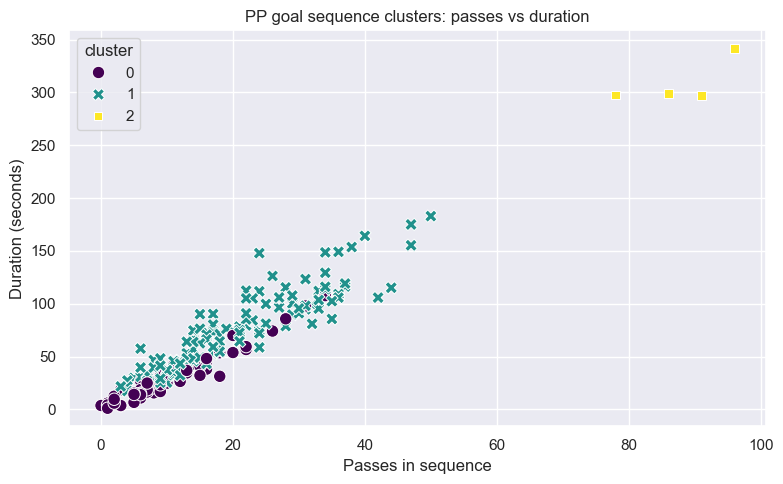

In [8]:
def create_seq_features(df_seqs):
    return df_seqs.groupby('goal_id').agg(
        x_mean=('xadjcoord', 'mean'),
        x_min=('xadjcoord', 'min'),
        y_std=('yadjcoord', 'std'),
        num_passes=('eventname', lambda x: (x == 'pass').sum()),
        num_carries=('eventname', lambda x: (x == 'carry').sum()),
        total_events=('eventname', 'count'),
        duration=('compiledgametime', lambda x: x.max() - x.min())
    ).fillna(0)

seq_feat_df = create_seq_features(pp_sequences)
X_seq = StandardScaler().fit_transform(seq_feat_df)
seq_feat_df['cluster'] = KMeans(n_clusters=3, random_state=42, n_init=10).fit_predict(X_seq)

if 'cluster' in pp_sequences.columns:
    pp_sequences = pp_sequences.drop(columns=['cluster'])
pp_sequences = pp_sequences.merge(seq_feat_df['cluster'].reset_index(), on='goal_id', how='left')

print('Average features per cluster:')
print(seq_feat_df.groupby('cluster').mean().round(2))

fig, ax = plt.subplots(figsize=(8, 5))
sns.scatterplot(data=seq_feat_df, x='num_passes', y='duration',
                hue='cluster', palette='viridis', s=80, style='cluster', ax=ax)
ax.set_title('PP goal sequence clusters: passes vs duration')
ax.set_xlabel('Passes in sequence'); ax.set_ylabel('Duration (seconds)')
plt.tight_layout(); plt.show()

# Zone entry type

### Shot quality after each entry type

/var/folders/v8/rkz49_9s6z71fq6sxs_b6zk40000gn/T/ipykernel_45845/1293643366.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=tagged_shots, x='entry_type', y='xg_allattempts', order=order,
/var/folders/v8/rkz49_9s6z71fq6sxs_b6zk40000gn/T/ipykernel_45845/1293643366.py:24: UserWarning: The palette list has more values (4) than needed (3), which may not be intended.
  sns.boxplot(data=tagged_shots, x='entry_type', y='xg_allattempts', order=order,


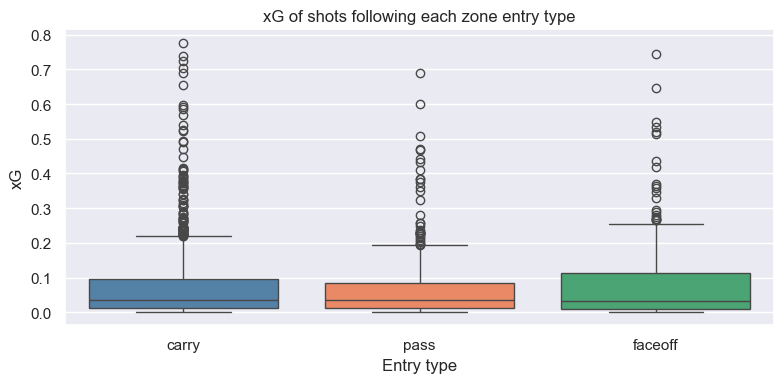

             count    mean     std     min     25%     50%     75%     max
entry_type                                                                
carry       1577.0  0.0696  0.0929  0.0015  0.0120  0.0348  0.0947  0.7765
faceoff      310.0  0.0809  0.1112  0.0016  0.0102  0.0336  0.1117  0.7440
pass         542.0  0.0651  0.0864  0.0014  0.0109  0.0346  0.0844  0.6902


In [9]:
pp_data = data[data['manpowersituation'] == 'powerPlay'].copy().sort_values(['gameid', 'compiledgametime'])

# Tag each shot with the most recent entry type in the same sequence
pp_data['time_gap'] = pp_data.groupby('gameid')['compiledgametime'].diff()
pp_data['new_seq']  = (pp_data['time_gap'] > 10) | pp_data['time_gap'].isna()
pp_data['seq_id']   = pp_data.groupby('gameid')['new_seq'].cumsum()

tagged = []
for (game, seq), grp in pp_data.groupby(['gameid', 'seq_id']):
    entries = grp[grp['eventname'] == 'controlledentry']['type']
    if len(entries) == 0: etype = 'faceoff'
    else:
        t = entries.iloc[0]
        etype = 'carry' if str(t).startswith('carry') else ('pass' if str(t).startswith('pass') else 'other')
    shots = grp[grp['eventname'].isin(['shot', 'goal'])].dropna(subset=['xg_allattempts']).copy()
    shots['entry_type'] = etype
    tagged.append(shots)

tagged_shots = pd.concat(tagged, ignore_index=True)

fig, ax = plt.subplots(figsize=(8, 4))
order = ['carry', 'pass', 'other', 'faceoff']
order = [o for o in order if o in tagged_shots['entry_type'].unique()]
sns.boxplot(data=tagged_shots, x='entry_type', y='xg_allattempts', order=order,
            palette=['steelblue','coral','mediumseagreen','gray'], ax=ax)
ax.set_title('xG of shots following each zone entry type')
ax.set_xlabel('Entry type'); ax.set_ylabel('xG')
plt.tight_layout(); plt.show()

print(tagged_shots.groupby('entry_type')['xg_allattempts'].describe().round(4))

# Puck movement and shot quality

#### Passes by the attacking team in the 10 seconds before each shot (same team in possession).

In [10]:
shots = pp_data[pp_data['eventname'].isin(['shot', 'goal'])].dropna(subset=['xg_allattempts', 'teaminpossession']).copy()

passes_df = pp_data[pp_data['eventname'] == 'pass'][
    ['gameid', 'teaminpossession', 'compiledgametime']
].dropna(subset=['teaminpossession']).copy().rename(columns={'compiledgametime': 'pass_time'})

counts = [] 
for game_id, g_shots in shots.groupby('gameid'):
    g_passes = passes_df[passes_df['gameid'] == game_id]
    for _, row in g_shots.iterrows():
        tp = g_passes[g_passes['teaminpossession'] == row['teaminpossession']]['pass_time'].values
        t  = row['compiledgametime']
        counts.append(int(((tp >= t - 10) & (tp < t)).sum()))

shots['passes_before'] = counts
shots.groupby('passes_before')['xg_allattempts'].agg(['mean', 'count']).head(10)

,mean,count
passes_before,,
0,0.050547,24
1,0.045053,174
2,0.056487,427
3,0.070210,622
4,0.073386,612
5,0.083210,379
6,0.092262,151
7,0.070081,38
8,0.032160,1


### Mann-Whitney U test – few vs many passes before shot

In [11]:
# ändra - kanske ta bort
few  = shots[shots['passes_before'] <= 2]['xg_allattempts']
many = shots[shots['passes_before'] >= 4]['xg_allattempts']
stat, p = stats.mannwhitneyu(few, many, alternative='less')

print(f'n (≤2 passes): {len(few)},  median xG = {few.median():.4f}')
print(f'n (≥4 passes): {len(many)},  median xG = {many.median():.4f}')
print(f'U = {stat:.0f},  p = {p:.4f}')
print('Significant (p < 0.05)' if p < 0.05 else 'Not significant')

n (≤2 passes): 625,  median xG = 0.0272
n (≥4 passes): 1182,  median xG = 0.0420
U = 301427,  p = 0.0000
Significant (p < 0.05)


### Bootstrap 95% CI on mean xG per pass count

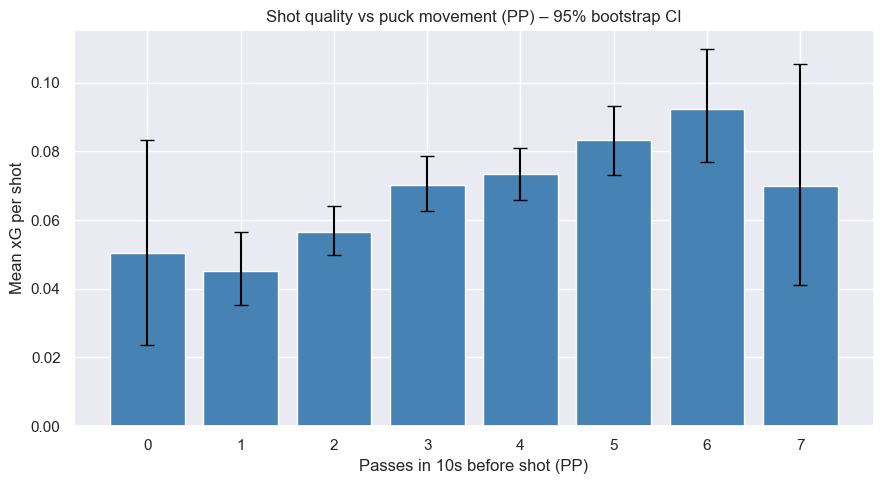

 passes   n  mean_xg  ci_lo  ci_hi
      0  24   0.0505 0.0236 0.0834
      1 174   0.0451 0.0352 0.0565
      2 427   0.0565 0.0499 0.0640
      3 622   0.0702 0.0626 0.0787
      4 612   0.0734 0.0660 0.0811
      5 379   0.0832 0.0730 0.0933
      6 151   0.0923 0.0769 0.1098
      7  38   0.0701 0.0412 0.1056


In [12]:
def bootstrap_ci(arr, n_boot=2000):
    arr = np.asarray(arr)
    means = [np.random.choice(arr, size=len(arr), replace=True).mean() for _ in range(n_boot)]
    return np.percentile(means, [2.5, 97.5])

rows = []
for n in range(0, 8):
    sub = shots[shots['passes_before'] == n]['xg_allattempts']
    if len(sub) < 10: continue
    lo, hi = bootstrap_ci(sub)
    rows.append({'passes': n, 'n': len(sub), 'mean_xg': sub.mean(), 'ci_lo': lo, 'ci_hi': hi})

ci_df = pd.DataFrame(rows)

fig, ax = plt.subplots(figsize=(9, 5))
ax.bar(ci_df['passes'], ci_df['mean_xg'], color='steelblue', edgecolor='white')
ax.errorbar(ci_df['passes'], ci_df['mean_xg'],
            yerr=[ci_df['mean_xg'] - ci_df['ci_lo'], ci_df['ci_hi'] - ci_df['mean_xg']],
            fmt='none', color='black', capsize=5, linewidth=1.5)
ax.set_xlabel('Passes in 10s before shot (PP)')
ax.set_ylabel('Mean xG per shot')
ax.set_title('Shot quality vs puck movement (PP) – 95% bootstrap CI')
plt.tight_layout(); plt.show()

print(ci_df[['passes', 'n', 'mean_xg', 'ci_lo', 'ci_hi']].round(4).to_string(index=False))

### Shot location heatmap (PP) – where do shots and goals originate?

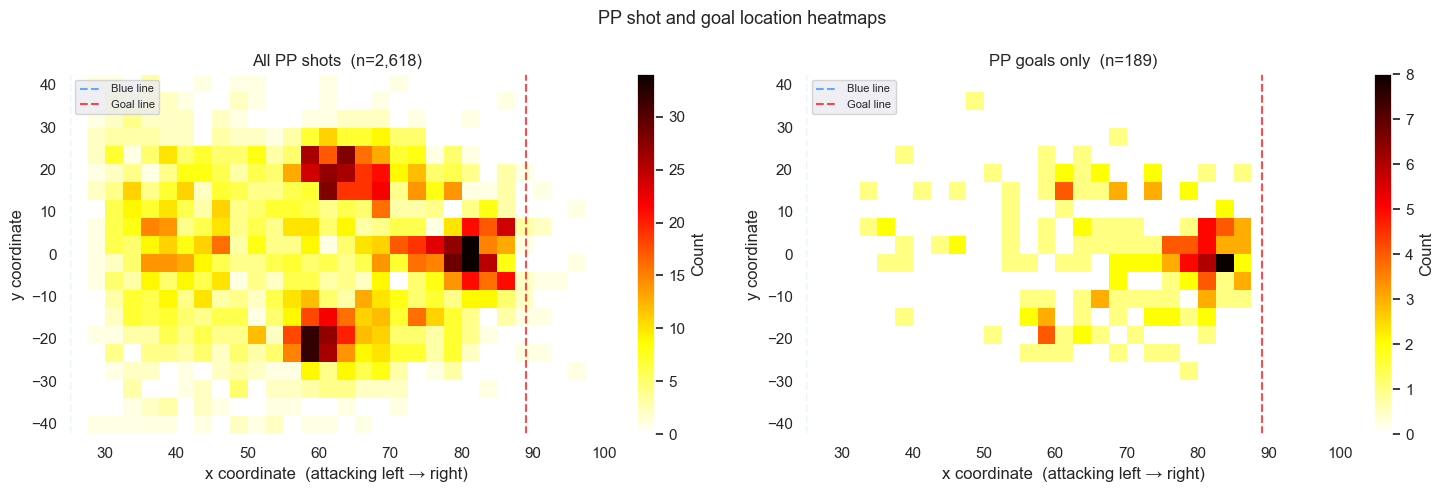

Median shot distance from goal:  33.1 ft
Median GOAL distance from goal:  20.7 ft


In [13]:
# ändra - fixa så den är mer lik andreas plot
pp_shots_loc = data[
    (data['manpowersituation'] == 'powerPlay') &
    (data['eventname'].isin(['shot', 'goal']))
].dropna(subset=['xadjcoord', 'yadjcoord'])

pp_goals_loc = pp_shots_loc[pp_shots_loc['eventname'] == 'goal']

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

for ax, subset, title in zip(
    axes,
    [pp_shots_loc, pp_goals_loc],
    [f'All PP shots  (n={len(pp_shots_loc):,})', f'PP goals only  (n={len(pp_goals_loc)})']
):
    h = ax.hist2d(
        subset['xadjcoord'], subset['yadjcoord'],
        bins=[30, 20], range=[[25, 100], [-42.5, 42.5]],
        cmap='hot_r'
    )
    plt.colorbar(h[3], ax=ax, label='Count')
    ax.axvline(25, color='dodgerblue', linewidth=1.5, alpha=0.7, linestyle='--', label='Blue line')
    ax.axvline(89, color='red',        linewidth=1.5, alpha=0.7, linestyle='--', label='Goal line')
    ax.set_xlim(25, 100); ax.set_ylim(-42.5, 42.5)
    ax.set_title(title)
    ax.set_xlabel('x coordinate  (attacking left → right)')
    ax.set_ylabel('y coordinate')
    ax.legend(fontsize=8)

plt.suptitle('PP shot and goal location heatmaps', fontsize=13)
plt.tight_layout()
plt.show()

# Median shot distance from goal (x=89)
pp_shots_loc = pp_shots_loc.copy()
pp_shots_loc['dist_to_goal'] = np.sqrt((pp_shots_loc['xadjcoord'] - 89)**2 + pp_shots_loc['yadjcoord']**2)
pp_goals_loc = pp_shots_loc[pp_shots_loc['eventname'] == 'goal']

print(f"Median shot distance from goal:  {pp_shots_loc['dist_to_goal'].median():.1f} ft")
print(f"Median GOAL distance from goal:  {pp_goals_loc['dist_to_goal'].median():.1f} ft")

# When in the PP do goals happen?

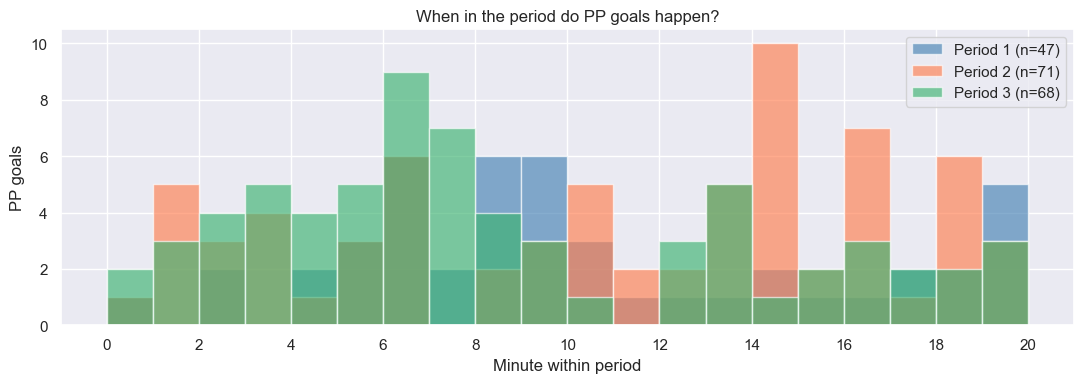

In [14]:
pp_goals_time = data[
    (data['manpowersituation'] == 'powerPlay') &
    (data['eventname'] == 'goal') &
    (data['period'].isin([1, 2, 3]))
].copy()

pp_goals_time['time_in_period_s'] = pp_goals_time['compiledgametime'] - (pp_goals_time['period'] - 1) * 1200
pp_goals_time['minute_in_period']  = pp_goals_time['time_in_period_s'] / 60
pp_goals_time['5min_bin']          = (pp_goals_time['minute_in_period'] // 5 * 5).clip(0, 15).astype(int)
pp_goals_time['5min_label']        = pp_goals_time['5min_bin'].astype(str) + '-' + (pp_goals_time['5min_bin'] + 5).astype(str)

fig, ax = plt.subplots(figsize=(11, 4))
period_colors = {1: 'steelblue', 2: 'coral', 3: 'mediumseagreen'}
for p in [1, 2, 3]:
    subset = pp_goals_time[pp_goals_time['period'] == p]['minute_in_period']
    ax.hist(subset, bins=20, range=(0, 20), alpha=0.65,
            label=f'Period {p} (n={len(subset)})', color=period_colors[p], edgecolor='white')
ax.set_xlabel('Minute within period'); ax.set_ylabel('PP goals')
ax.set_xticks(range(0, 21, 2)); ax.legend()
ax.set_title('When in the period do PP goals happen?')
plt.tight_layout(); plt.show()

### PP goals by period × 5-minute segment

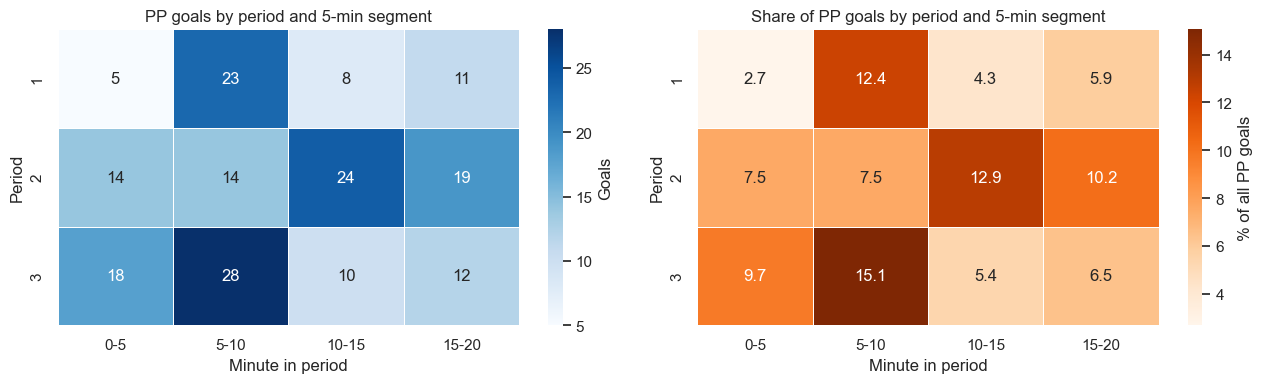

In [15]:
bin_labels = ['0-5', '5-10', '10-15', '15-20']
goal_matrix  = pp_goals_time.groupby(['period', '5min_label']).size().unstack(fill_value=0).reindex(columns=bin_labels, fill_value=0)
share_matrix = (goal_matrix / goal_matrix.values.sum() * 100).round(2)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
sns.heatmap(goal_matrix,  annot=True, fmt='d',   cmap='Blues',   ax=axes[0], linewidths=0.5, cbar_kws={'label': 'Goals'})
axes[0].set_title('PP goals by period and 5-min segment')
axes[0].set_xlabel('Minute in period'); axes[0].set_ylabel('Period')
sns.heatmap(share_matrix, annot=True, fmt='.1f', cmap='Oranges', ax=axes[1], linewidths=0.5, cbar_kws={'label': '% of all PP goals'})
axes[1].set_title('Share of PP goals by period and 5-min segment')
axes[1].set_xlabel('Minute in period'); axes[1].set_ylabel('Period')
plt.tight_layout(); plt.show()

### Score differential when PP goal is scored

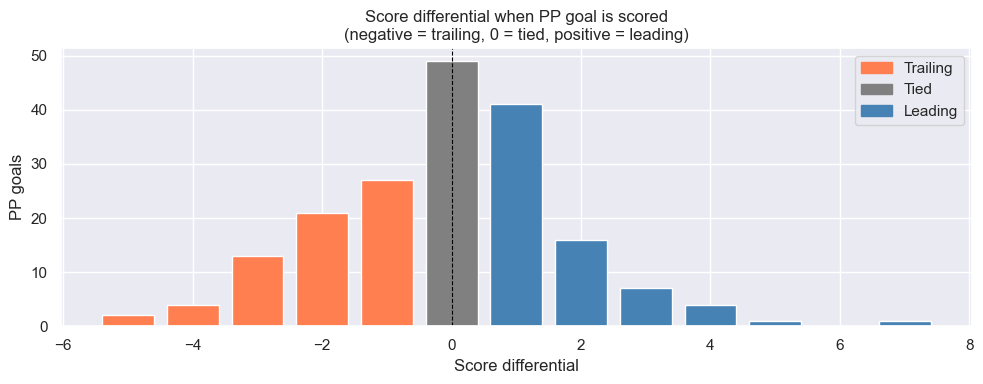

In [16]:
score_counts = pp_goals_time['scoredifferential'].value_counts().sort_index()
colors = ['coral' if x < 0 else 'steelblue' if x > 0 else 'gray' for x in score_counts.index]

fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(score_counts.index, score_counts.values, color=colors, edgecolor='white')
ax.set_title('Score differential when PP goal is scored\n(negative = trailing, 0 = tied, positive = leading)')
ax.set_xlabel('Score differential'); ax.set_ylabel('PP goals')
ax.axvline(0, color='black', linewidth=0.8, linestyle='--')
ax.legend(handles=[Patch(color='coral', label='Trailing'), Patch(color='gray', label='Tied'), Patch(color='steelblue', label='Leading')])
plt.tight_layout(); plt.show()

# PP conversion rate per team

#### Bootstrap CI with 1000 iterations.

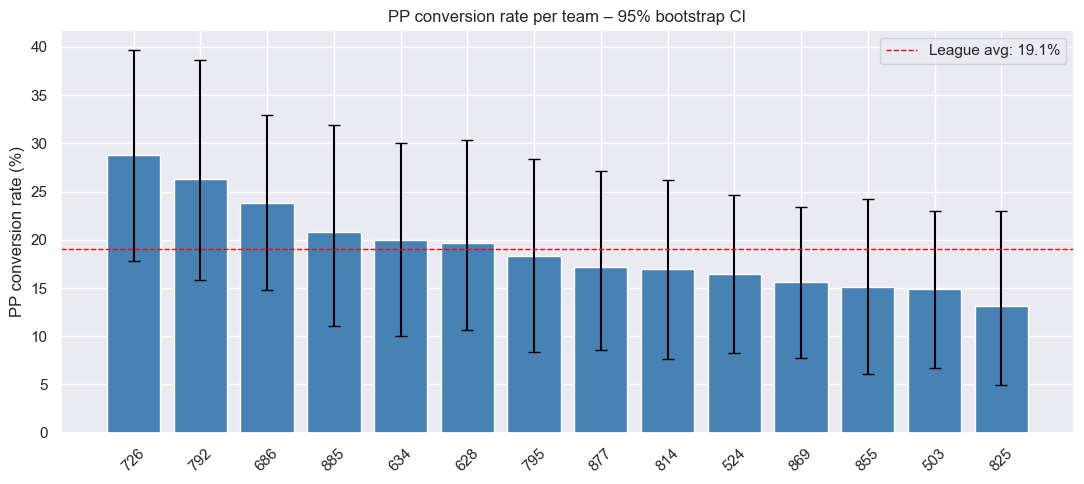

 teamid    pp_pct  n     ci_lo     ci_hi
    726 28.767123 73 17.808219 39.726027
    792 26.315789 57 15.789474 38.596491
    686 23.863636 88 14.772727 32.954545
    885 20.833333 72 11.111111 31.944444
    634 20.000000 60 10.000000 30.000000
    628 19.696970 66 10.606061 30.303030
    795 18.333333 60  8.333333 28.333333
    877 17.142857 70  8.571429 27.142857
    814 16.923077 65  7.692308 26.153846
    524 16.438356 73  8.219178 24.657534
    869 15.584416 77  7.792208 23.376623
    855 15.151515 66  6.060606 24.242424
    503 14.864865 74  6.756757 22.972973
    825 13.114754 61  4.918033 22.950820


In [17]:
team_conv_df = seq_df.groupby('teamid').agg(
    pp_pct=('goal', lambda x: x.mean() * 100),
    n=('goal', 'count')
).reset_index()

def bootstrap_rate_ci(arr, n_boot=1000):
    arr = np.array(arr)
    means = [np.random.choice(arr, size=len(arr), replace=True).mean() for _ in range(n_boot)]
    return np.percentile(means, 2.5) * 100, np.percentile(means, 97.5) * 100

cis = [bootstrap_rate_ci(seq_df[seq_df['teamid'] == t]['goal'].values) for t in team_conv_df['teamid']]
team_conv_df['ci_lo'] = [c[0] for c in cis]
team_conv_df['ci_hi'] = [c[1] for c in cis]
team_conv_df = team_conv_df.sort_values('pp_pct', ascending=False)

fig, ax = plt.subplots(figsize=(11, 5))
x = range(len(team_conv_df))
ax.bar(x, team_conv_df['pp_pct'], color='steelblue', edgecolor='white')
ax.errorbar(x, team_conv_df['pp_pct'],
            yerr=[team_conv_df['pp_pct'] - team_conv_df['ci_lo'],
                  team_conv_df['ci_hi'] - team_conv_df['pp_pct']],
            fmt='none', color='black', capsize=4, linewidth=1.5)
ax.set_xticks(x); ax.set_xticklabels(team_conv_df['teamid'], rotation=45)
ax.set_ylabel('PP conversion rate (%)')
ax.set_title('PP conversion rate per team – 95% bootstrap CI')
ax.axhline(team_conv_df['pp_pct'].mean(), color='red', linestyle='--', linewidth=1,
           label=f'League avg: {team_conv_df["pp_pct"].mean():.1f}%')
ax.legend(); plt.tight_layout(); plt.show()

print(team_conv_df.to_string(index=False))

# Team playing style in PP

#### K-Means clustering on 5 features. Linked to conversion rate to see if style correlates with efficiency.

In [18]:
pp_entries_style = data[
    (data['eventname'] == 'controlledentry') &
    (data['manpowersituation'] == 'powerPlay')
].copy()
pp_entries_style['entry_type'] = pp_entries_style['type'].apply(
    lambda x: 'carry' if str(x).startswith('carry') else ('pass' if str(x).startswith('pass') else 'other')
)
pp_entries_style['corridor'] = pp_entries_style['yadjcoord'].apply(
    lambda y: 'center' if -14 <= y <= 14 else ('left' if y > 14 else 'right')
)

pp_passes_style = data[
    (data['manpowersituation'] == 'powerPlay') &
    (data['eventname'] == 'pass') &
    (data['xadjcoord'] > 20)
].copy()

def assign_zone(row):
    x, y = row['xadjcoord'], row['yadjcoord']
    if x < 50:    return 'point'
    elif x >= 80: return 'behind_net'
    elif y < -15: return 'left_circle'
    elif y > 15:  return 'right_circle'
    else:         return 'slot'

pp_passes_style['zone'] = pp_passes_style.apply(assign_zone, axis=1)

team_rows = []
for team in data['teamid'].unique():
    ent = pp_entries_style[pp_entries_style['teamid'] == team]
    pas = pp_passes_style[pp_passes_style['teamid'] == team]
    if len(ent) < 10 or len(pas) < 20: continue
    team_rows.append({
        'teamid':     team,
        'carry_pct':  (ent['entry_type'] == 'carry').mean() * 100,
        'pass_pct':   (ent['entry_type'] == 'pass').mean()  * 100,
        'center_pct': (ent['corridor']   == 'center').mean()* 100,
        'slot_pct':   (pas['zone']       == 'slot').mean()  * 100,
        'point_pct':  (pas['zone']       == 'point').mean() * 100,
    })

style_df = pd.DataFrame(team_rows)
feat_cols = ['carry_pct', 'pass_pct', 'center_pct', 'slot_pct', 'point_pct']

X = StandardScaler().fit_transform(style_df[feat_cols])
style_df['cluster'] = KMeans(n_clusters=3, random_state=42, n_init=10).fit_predict(X)

means = style_df.groupby('cluster')[feat_cols].mean()
label_map = {
    'carry_pct':  'Carry-heavy',
    'pass_pct':   'Pass-based',
    'slot_pct':   'Slot-focused',
    'point_pct':  'Point-oriented',
    'center_pct': 'Center corridor',
}

# Fix: use z-scores of cluster means so the *most distinctive* feature per cluster
# wins the label, not just the feature with the highest absolute value (which is
# always carry_pct and causes all clusters to get the same label).
means_z = (means - means.mean()) / means.std()
style_df['style'] = style_df['cluster'].map(
    {c: label_map.get(means_z.loc[c].idxmax(), f'Style {c+1}') for c in means_z.index}
)

pp_lookup = team_conv_df.set_index('teamid')['pp_pct']
style_df['pp_pct'] = style_df['teamid'].map(pp_lookup)

print('Cluster means (raw %):')
print(means.round(1))
print('\nZ-scored cluster means (used for labeling):')
print(means_z.round(2))
print('\nMean PP% per style:')
print(style_df.groupby('style')[['pp_pct']].mean().round(2))

Cluster means (raw %):
         carry_pct  pass_pct  center_pct  slot_pct  point_pct
cluster                                                      
0             66.1      33.9        19.6       3.1       35.4
1             79.8      20.2        18.9       2.7       40.8
2             76.7      23.3        14.8       2.1       35.7

Z-scored cluster means (used for labeling):
         carry_pct  pass_pct  center_pct  slot_pct  point_pct
cluster                                                      
0            -1.13      1.13        0.70      0.92      -0.63
1             0.78     -0.78        0.44      0.14       1.15
2             0.35     -0.35       -1.15     -1.06      -0.52

Mean PP% per style:
                pp_pct
style                 
Carry-heavy      17.45
Pass-based       23.21
Point-oriented   17.34


### Radar chart – average style per cluster

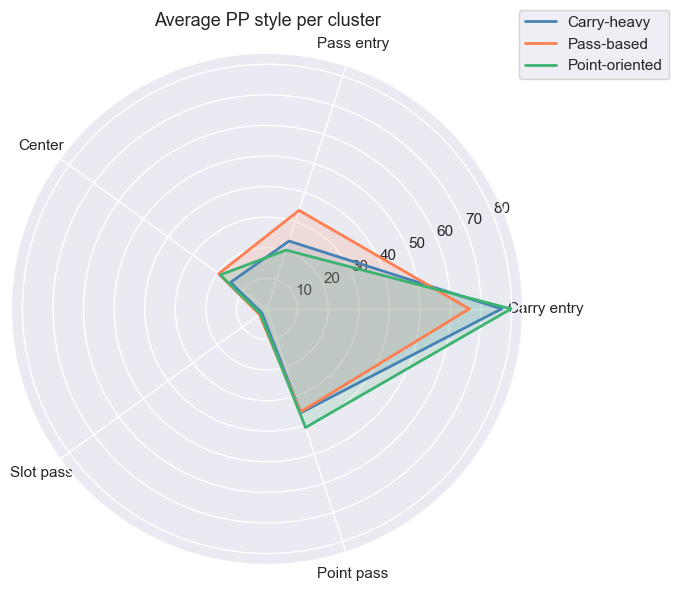

In [19]:
categories = ['carry_pct', 'pass_pct', 'center_pct', 'slot_pct', 'point_pct']
labels = ['Carry entry', 'Pass entry', 'Center', 'Slot pass', 'Point pass']
N = len(categories)
angles = [n / float(N) * 2 * np.pi for n in range(N)] + [0]

fig, ax = plt.subplots(figsize=(7, 7), subplot_kw=dict(polar=True))
palette = ['steelblue', 'coral', 'mediumseagreen']

for i, (style, grp) in enumerate(style_df.groupby('style')):
    vals = grp[categories].mean().tolist() + [grp[categories].mean().tolist()[0]]
    ax.plot(angles, vals, color=palette[i], linewidth=2, label=style)
    ax.fill(angles, vals, color=palette[i], alpha=0.15)

ax.set_xticks(angles[:-1]); ax.set_xticklabels(labels, size=11)
ax.set_title('Average PP style per cluster', size=13, pad=20)
ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1))
plt.tight_layout(); plt.show()

### PP conversion rate by playing style

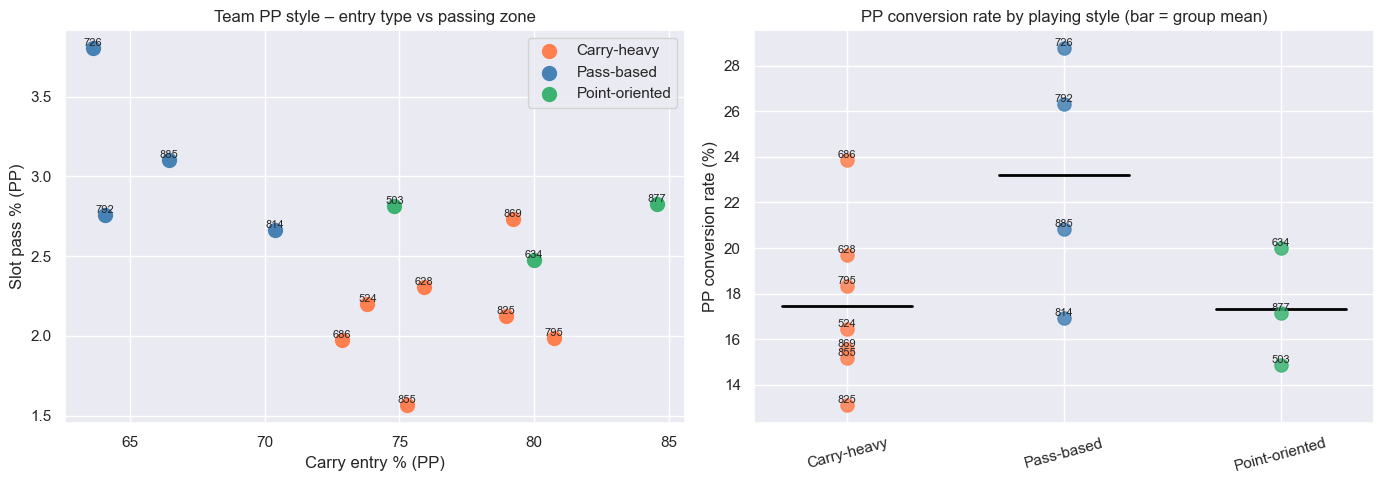

In [20]:
palette = dict(zip(style_df['style'].unique(), ['steelblue', 'coral', 'mediumseagreen']))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for style, grp in style_df.groupby('style'):
    axes[0].scatter(grp['carry_pct'], grp['slot_pct'], label=style, s=100, color=palette.get(style, 'gray'))
    for _, row in grp.iterrows():
        axes[0].annotate(str(row['teamid']), (row['carry_pct'], row['slot_pct']), fontsize=8, ha='center', va='bottom')
axes[0].set_xlabel('Carry entry % (PP)'); axes[0].set_ylabel('Slot pass % (PP)')
axes[0].set_title('Team PP style – entry type vs passing zone'); axes[0].legend()

style_order = sorted(style_df['style'].unique())
for i, s in enumerate(style_order):
    grp = style_df[style_df['style'] == s]
    axes[1].scatter([i] * len(grp), grp['pp_pct'], s=90, color=palette.get(s, 'gray'), alpha=0.85, zorder=3)
    for _, row in grp.iterrows():
        axes[1].annotate(str(row['teamid']), (i, row['pp_pct']), fontsize=8, ha='center', va='bottom')
    axes[1].plot([i-0.3, i+0.3], [grp['pp_pct'].mean()]*2, color='black', linewidth=2)

axes[1].set_xticks(range(len(style_order))); axes[1].set_xticklabels(style_order, rotation=15)
axes[1].set_ylabel('PP conversion rate (%)')
axes[1].set_title('PP conversion rate by playing style (bar = group mean)')
plt.tight_layout(); plt.show()

### Where shots was made from each team

In [21]:
# Sort data by game and time
df = sorted_data.sort_values(['gameid', 'compiledgametime']).copy()

# Find start of each power play
df['is_pp'] = (df['manpowersituation'] == 'powerPlay').astype(int)
df['pp_start'] = (df['is_pp'] == 1) & (df['is_pp'].shift(1) == 0)
df['pp_id'] = df.groupby('gameid')['pp_start'].cumsum()

# Check if a power play spans multiple periods
pp_info = df[df['is_pp'] == 1].groupby(['gameid', 'pp_id']).agg({
    'period': ['min', 'max', 'nunique'],
    'eventname': lambda x: (x == 'goal').any()  # goal scored in PP
}).reset_index()

pp_info.columns = ['gameid', 'pp_id', 'period_min', 'period_max', 'period_count', 'made_goal']

# Label PP as continuous or interrupted
pp_info['category'] = 'Continuous'
pp_info.loc[pp_info['period_count'] > 1, 'category'] = 'Interrupted'

# Calculate goal percentage
resultat = pp_info.groupby('category')['made_goal'].mean() * 100

print("Power play goal percentage:")
print(resultat)

# Show number of PP in each category
print("\nNumber of power plays per category:")
print(pp_info['category'].value_counts())

# Show total situations
print(df['manpowersituation'].value_counts())

Power play goal percentage:
category
Continuous     1.853486
Interrupted    0.000000
Name: made_goal, dtype: float64

Number of power plays per category:
category
Continuous     10197
Interrupted       11
Name: count, dtype: int64
manpowersituation
evenStrength    463668
powerPlay        59271
shortHanded      18863
Name: count, dtype: int64


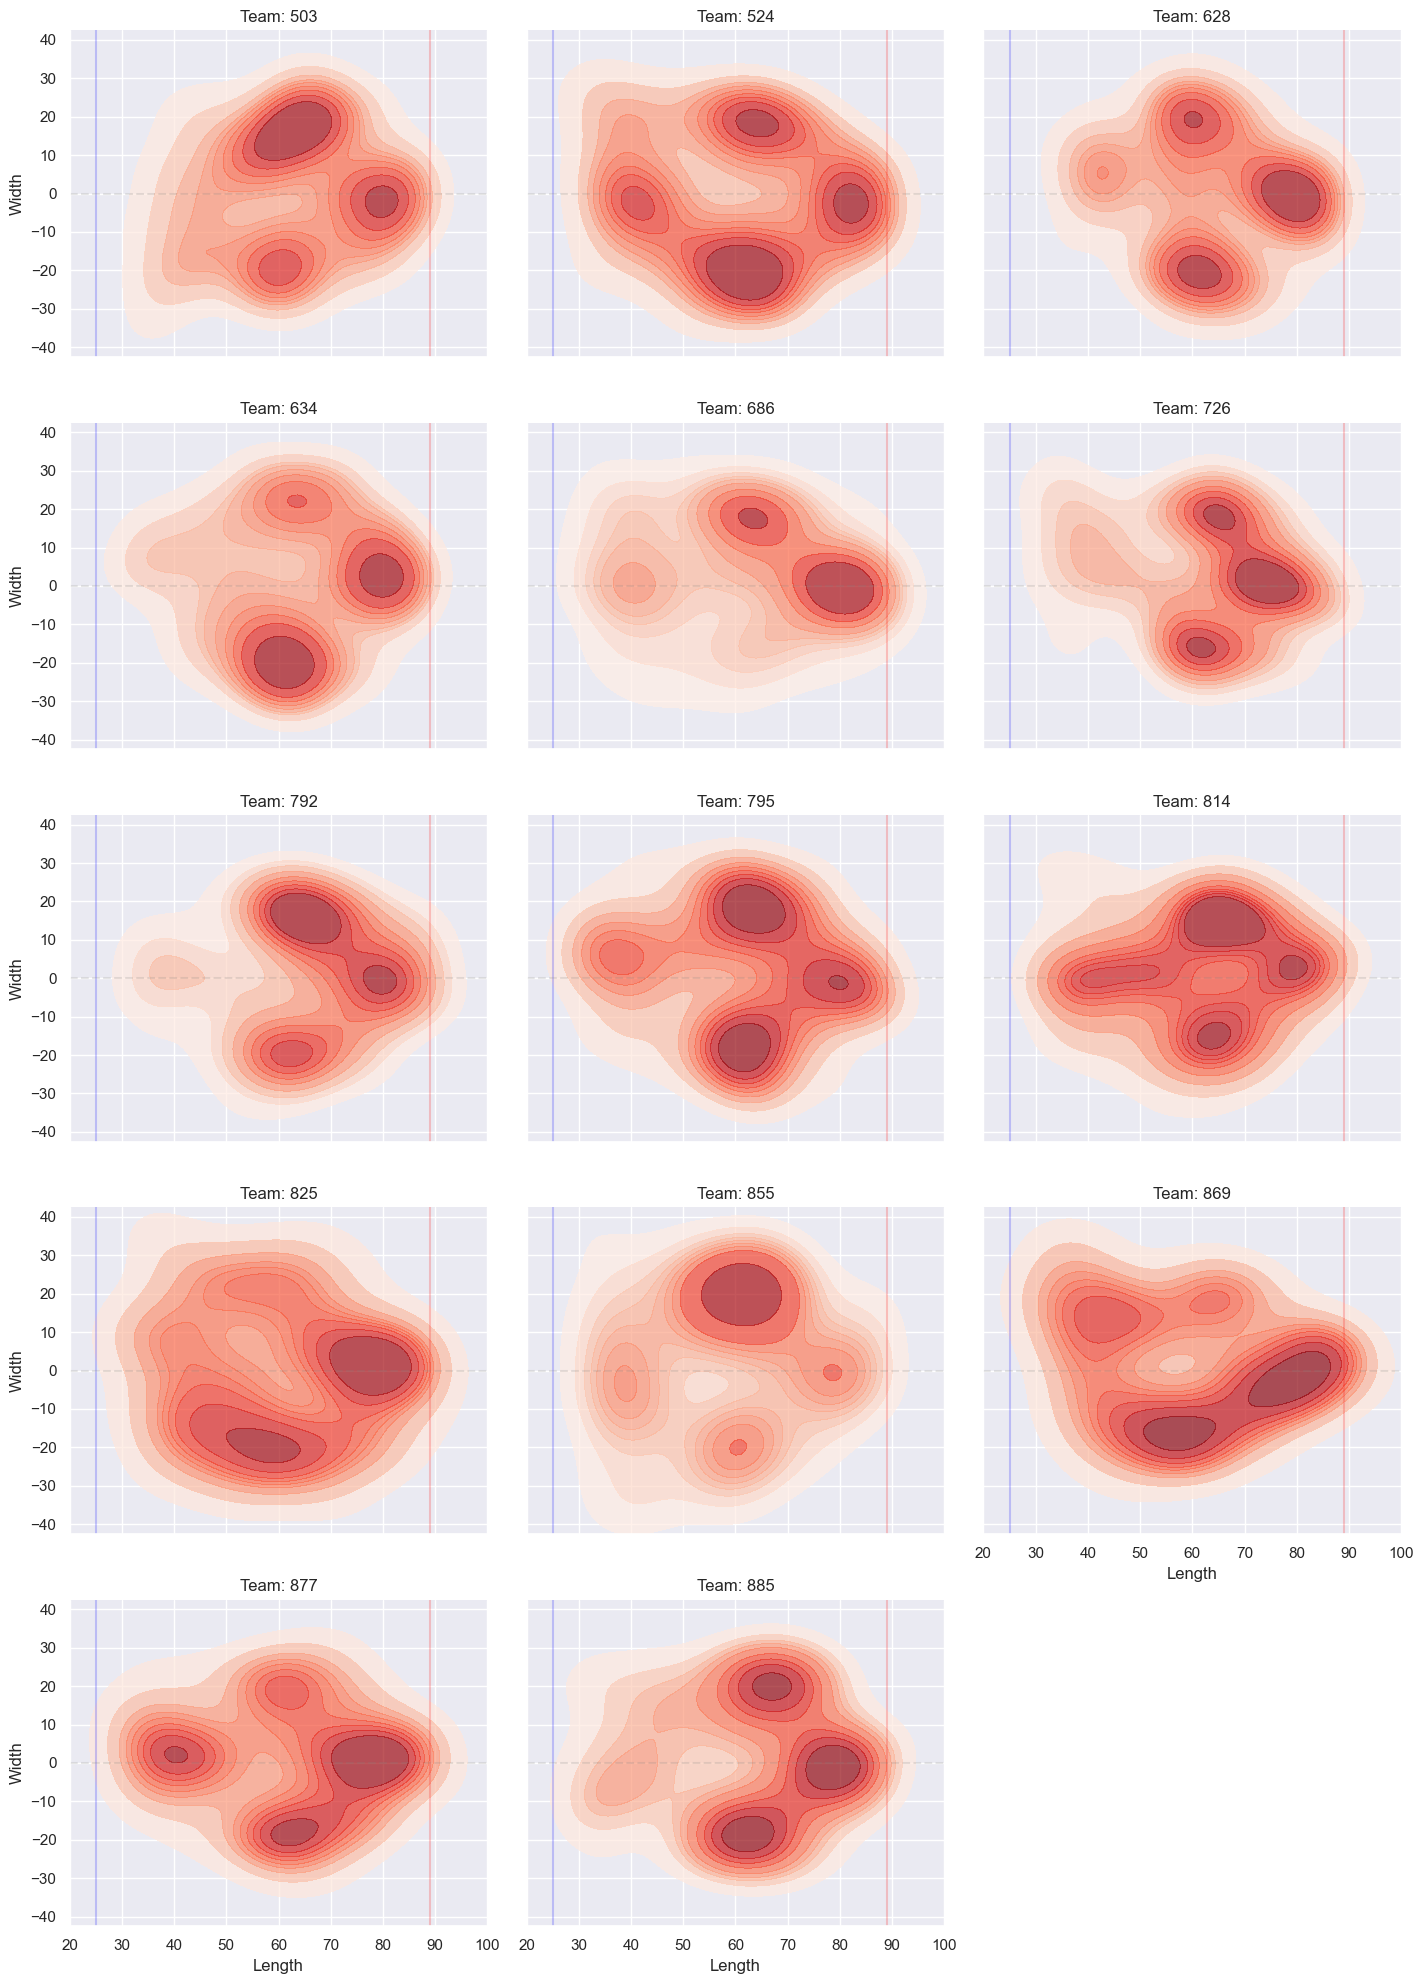

side    Left  Right  Left_Percent
teamid                           
855       91     65     58.333333
686      148    116     56.060606
726      135    114     54.216867
877       92     79     53.801170
634       76     67     53.146853
795       91     83     52.298851
814       97     90     51.871658
825       64     61     51.200000
869      101     97     51.010101
628       81     79     50.625000
885      104    102     50.485437
503      115    116     49.783550
792       71     72     49.650350
524       95    116     45.023697


In [22]:
# Filter shots in power play (shots + goals)
pp_shots = df[
    (df['manpowersituation'] == 'powerPlay') & 
    ((df['eventname'] == 'shot') | (df['eventname'] == 'goal'))
].copy()

# Get teams with most shots
top_teams = pp_shots['teamid'].value_counts().index
filter_df = pp_shots[pp_shots['teamid'].isin(top_teams)]

# Create grid of plots (one per team)
g = sns.FacetGrid(filter_df, col="teamid", col_wrap=3, height=4, aspect=1.2)

# Draw simple rink lines
def draw_rink_mini(*args, **kwargs):
    plt.axvline(25, color='blue', alpha=0.2)   # blue line
    plt.axvline(89, color='red', alpha=0.2)    # goal line
    plt.axhline(0, color='grey', linestyle='--', alpha=0.2)

g.map(draw_rink_mini)

# Add heatmap of shot locations
g.map_dataframe(
    sns.kdeplot,
    x="xadjcoord",
    y="yadjcoord",
    fill=True,
    cmap="Reds",
    alpha=0.7,
    thresh=0.1
)

# Set axis limits and labels
g.set(xlim=(20, 100), ylim=(-42.5, 42.5))
g.set_axis_labels("Length", "Width")
g.set_titles("Team: {col_name}")

plt.tight_layout()
plt.show()

# Create left/right side column
pp_shots['side'] = pp_shots['yadjcoord'].apply(
    lambda y: 'Left' if y > 0 else 'Right'
)

# Count shots per side and team
side_distribution = pp_shots.groupby(['teamid', 'side']).size().unstack(fill_value=0)

# Calculate left side percentage
side_distribution['Left_Percent'] = (
    side_distribution['Left'] /
    (side_distribution['Left'] + side_distribution['Right'])
) * 100

# Show result sorted by left side %
print(side_distribution.sort_values(by='Left_Percent', ascending=False))